In [8]:
import os
import glob
import copy
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from omegaconf import OmegaConf, ListConfig
from tqdm import tqdm
from lightning_pose.api.model import Model
from lightning_pose.utils.scripts import get_data_module, get_dataset, get_imgaug_transform
from lightning_pose.data.utils import convert_bbox_coords
from lightning_pose.utils.predictions import make_dlc_pandas_index

# -----------------------------------------------------------------------------
# 1. Configuration & Paths
# -----------------------------------------------------------------------------
# dataset_name = "fly-anipose"
# dataset_name = "chickadee-crop"
# dataset_name = "mirror-mouse-separate"
dataset_name = "ibl-mouse"
# dataset_name = "two-mouse"

# OUTPUT_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

MODELS_CONFIG = {
    "SVT": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_SV_vits_dino",
    # "SVT": f"/teamspace/studios/iclr-2026/outputs/{dataset_name}/test_200_SV_vits_dino",
    # "MVT": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_dlc",
    "MVT_3d_aug": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_3d_aug",
    # "MVT_patch_masking": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_patch_masking_no3d_loss",
    # "MVT_3d_loss": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_3d_loss_(0_3)",
    # "MVT++": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_3d_loss_patch_masking_new"
    # "MVT++": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_3d_aug_patch_masking"
    # "MVT++": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_400_MVT_3d_loss_patch_masking"
    "MVT++": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_dlc"
}

# MODELS_CONFIG = {
#     "SVT": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_SV_vits_dino",
#     "MVT": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_dlc",
#     "MVT++": f"/teamspace/studios/this_studio/outputs/{dataset_name}/test_200_MVT_patch_masking",
# }

SEED = 0
OOD_DATA_DIR = f"/teamspace/studios/data/{dataset_name}"
BATCH_SIZE = 8
OUTPUT_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR_seed{SEED}_r2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find OOD CSV files
ood_csv_files = sorted(list(Path(OOD_DATA_DIR).glob("CollectedData_*_new.csv")))
print(f"Found {len(ood_csv_files)} OOD CSV files.")


# -----------------------------------------------------------------------------
# 2. Helper Functions
# -----------------------------------------------------------------------------

def find_model_run_path(base_path, seed):
    candidates = list(Path(base_path).glob(f"*_{seed}"))
    if not candidates:
        if (Path(base_path) / "config.yaml").exists(): return base_path
        raise ValueError(f"Could not find run directory for seed {seed} in {base_path}")
    for c in candidates:
        if (c / "config.yaml").exists(): return str(c)
    return str(candidates[0])

def get_inference_dataloader(model, csv_files, data_dir):
    """
    Creates a dataloader that strictly mimics the training setup but for OOD files.
    """
    # Force imgaug to default (resize only)
    cfg_overrides = {
        "data": {
            "data_dir": str(data_dir),
            "csv_file": [str(f) for f in csv_files],
            "camera_params_file": None, # Disable calibration checks for simple inference
            "mirrored_column_matches": None, 
            "bbox_file": None, # <--- IMPORTANT FIX: Disable bbox loading for OOD
        },
        "training": {
            "imgaug": "default" 
        }
    }
    
    # Merge and ensure deep copy to avoid modifying original cfg
    cfg_pred = OmegaConf.merge(model.cfg, cfg_overrides)
    
    # Verify data existence (Quick Check)
    try:
        df = pd.read_csv(csv_files[0], header=[0,1,2], index_col=0)
        first_img_rel = df.index[0]
        first_img_abs = Path(data_dir) / first_img_rel
        if not first_img_abs.exists():
            print(f"WARNING: Image path check failed. {first_img_abs} does not exist!")
        else:
            print(f"Data check passed. Found {first_img_abs}")
    except Exception as e:
        print(f"Data check skipped/failed: {e}")
    
    imgaug_transform = get_imgaug_transform(cfg=cfg_pred)
    dataset = get_dataset(
        cfg=cfg_pred,
        data_dir=cfg_pred.data.data_dir,
        imgaug_transform=imgaug_transform,
    )
    data_module = get_data_module(
        cfg=cfg_pred, 
        dataset=dataset, 
        video_dir=cfg_pred.data.video_dir
    )
    return data_module.full_labeled_dataloader()

def run_inference_and_save(model_wrapper, dataloader, output_base, model_name, device="cuda"):
    """
    Runs masked inference and saves results in the specified format.
    """
    pl_model = model_wrapper.model
    pl_model.eval()
    pl_model.to(device)
    
    # Ensure config lists are standard python lists
    view_names = list(model_wrapper.config.cfg.data.view_names)
    keypoint_names = list(model_wrapper.config.cfg.data.keypoint_names)
    
    num_views = len(view_names)
    num_kps_per_view = len(keypoint_names)
    total_kps = num_views * num_kps_per_view
    
    print(f"\nRunning inference for {model_name}...")
    
    # Initialize results container: [masked_view] -> {preds, confs, targets}
    results = {view: {"preds": [], "confs": [], "targets": [], "filenames": []} for view in view_names}
    
    full_dataset = dataloader.dataset
    
    with torch.no_grad():
        for batch_idx, batch in tqdm(enumerate(dataloader), total=len(dataloader), desc="Batches"):
            # Move data to device
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch[k] = v.to(device)
            
            images = batch["images"]
            
            # DEBUG: Check if images are identical (only first batch)
            if batch_idx == 0:
                img_sum = images.sum().item()
                print(f"DEBUG: Batch 0 Image Sum: {img_sum}")
                if img_sum == 0:
                    print("CRITICAL WARNING: Input images are all zeros!")
            
            # Get Ground Truth (Targets)
            if "keypoints" in batch:
                # convert_bbox_coords transforms normalized/cropped coords back to original image pixel space
                targets_orig = convert_bbox_coords(batch, batch["keypoints"])
                t_np = targets_orig.cpu().numpy()
                # Reshape to (B, Total_KPs, 2) if flattened
                if len(t_np.shape) == 2:
                    t_np = t_np.reshape(t_np.shape[0], total_kps, 2)
                targets_np = t_np
            else:
                targets_np = None

            # Iterate over each view to mask it
            for mask_idx, mask_view in enumerate(view_names):
                masked_images = images.clone()
                # Masking: Set the specific view channel to 0.0
                # Shape: (B, Views, C, H, W)
                masked_images[:, mask_idx, :, :, :] = 0.0
                
                masked_batch = batch.copy()
                masked_batch["images"] = masked_images
                
                # Predict
                preds, confs = pl_model.predict_step(masked_batch, batch_idx, return_heatmaps=False)
                
                p_np = preds.cpu().numpy()
                c_np = confs.cpu().numpy()
                
                # Ensure prediction shape consistency (B, Total_KPs, 2)
                if len(p_np.shape) == 2:
                    p_np = p_np.reshape(p_np.shape[0], total_kps, 2)
                
                results[mask_view]["preds"].append(p_np)
                results[mask_view]["confs"].append(c_np)
                if targets_np is not None:
                    results[mask_view]["targets"].append(targets_np)
                
    print(f"\nSaving results for {model_name}...")
    
    model_out_dir = os.path.join(output_base, model_name)
    os.makedirs(model_out_dir, exist_ok=True)
    
    for mask_view in view_names:
        # Folder for this masking condition
        mask_out_dir = os.path.join(model_out_dir, f"masked_{mask_view}")
        os.makedirs(mask_out_dir, exist_ok=True)
        
        # Aggregate batch results
        all_preds = np.concatenate(results[mask_view]["preds"], axis=0)
        all_confs = np.concatenate(results[mask_view]["confs"], axis=0)
        
        if results[mask_view]["targets"]:
            all_targets = np.concatenate(results[mask_view]["targets"], axis=0)
        else:
            all_targets = None
            
        n_samples = all_preds.shape[0]
        
        # Split and Save Per Target View
        for target_idx, target_view in enumerate(view_names):
            start = target_idx * num_kps_per_view
            end = (target_idx + 1) * num_kps_per_view
            
            view_preds = all_preds[:, start:end, :] 
            view_confs = all_confs[:, start:end]    
            
            # --- Filename Logic ---
            # Try to get specific filenames for this target view
            filenames = None
            if hasattr(full_dataset, "dataset") and isinstance(full_dataset.dataset, dict):
                if target_view in full_dataset.dataset:
                    filenames = full_dataset.dataset[target_view].image_names
            
            # Fallback
            if filenames is None:
                if hasattr(full_dataset, "image_names"):
                     filenames = full_dataset.image_names
                elif hasattr(full_dataset, "image_paths"):
                     filenames = full_dataset.image_paths
                else:
                     filenames = [f"img{i:06d}.png" for i in range(n_samples)]
            
            # Align length
            if len(filenames) != n_samples:
                filenames = filenames[:n_samples]

            # --- 1. Save Predictions CSV ---
            # Explicitly cast to list to fix TypeError
            pd_index = make_dlc_pandas_index(model_wrapper.cfg, list(keypoint_names))
            
            # Flatten for DataFrame: x1, y1, lik1, x2, y2, lik2...
            flat_data = np.zeros((n_samples, num_kps_per_view * 3))
            flat_data[:, 0::3] = view_preds[:, :, 0]
            flat_data[:, 1::3] = view_preds[:, :, 1]
            flat_data[:, 2::3] = view_confs
            
            df_pred = pd.DataFrame(flat_data, columns=pd_index, index=filenames)
            df_pred["set"] = "unused"
            
            # CORRECT FILENAME FORMAT
            pred_filename = f"CollectedData_{target_view}_new.csv"
            pred_path = os.path.join(mask_out_dir, pred_filename)
            df_pred.to_csv(pred_path)
            
            # --- 2. Compute and Save Pixel Error ---
            if all_targets is not None:
                view_targets = all_targets[:, start:end, :]
                # Euclidean distance
                errors = np.linalg.norm(view_preds - view_targets, axis=2)
                
                df_err = pd.DataFrame(errors, columns=keypoint_names, index=filenames)
                df_err["set"] = "unused"
                
                err_filename = f"CollectedData_{target_view}_new_pixel_error.csv"
                err_path = os.path.join(mask_out_dir, err_filename)
                df_err.to_csv(err_path)

                # --- 3. R² (coordinate-level, pooled x and y over frames × keypoints) ---
                t_flat = view_targets.reshape(-1, 2).astype(np.float64)
                p_flat = view_preds.reshape(-1, 2).astype(np.float64)
                valid = np.isfinite(t_flat).all(axis=1) & np.isfinite(p_flat).all(axis=1)
                t_flat = t_flat[valid]
                p_flat = p_flat[valid]
                if len(t_flat) > 0:
                    ss_res = np.sum((t_flat - p_flat) ** 2)
                    ss_tot = (
                        np.sum((t_flat[:, 0] - t_flat[:, 0].mean()) ** 2)
                        + np.sum((t_flat[:, 1] - t_flat[:, 1].mean()) ** 2)
                    )
                    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else float("nan")
                else:
                    r2 = float("nan")
                r2_filename = f"CollectedData_{target_view}_new_r2.csv"
                r2_path = os.path.join(mask_out_dir, r2_filename)
                pd.DataFrame([{"r2": r2, "n_points": int(len(t_flat))}]).to_csv(
                    r2_path, index=False
                )

                
        print(f"  Saved output for masked view: {mask_view}")

# -----------------------------------------------------------------------------
# 3. Main Loop
# -----------------------------------------------------------------------------

for model_key, model_base_path in MODELS_CONFIG.items():
    print(f"\n{'='*50}\nProcessing Model: {model_key}\n{'='*50}")
    
    try:
        run_path = find_model_run_path(model_base_path, SEED)
        print(f"Loading from: {run_path}")
        model = Model.from_dir(run_path)
        model._load() 
        
        dataloader = get_inference_dataloader(model, ood_csv_files, OOD_DATA_DIR)
        print(f"Dataloader ready. Batches: {len(dataloader)}")
        
        run_inference_and_save(model, dataloader, OUTPUT_DIR, model_key)
        
        del model
        del dataloader
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"Error processing {model_key}: {e}")
        import traceback
        traceback.print_exc()

print(f"\nAll done! Results saved to {OUTPUT_DIR}")

Found 2 OOD CSV files.

Processing Model: SVT
Loading from: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_SV_vits_dino/supervised_200_0
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL omegaconf.dictconfig.DictConfig was not an allowed global by default. Please use `torch.serialization.add_safe_globals([omegaconf.dictconfig.DictConfig])` or the `torch.serialization.safe_globals([omegaconf.dictconfig.DictConfig])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accept

Batches:   5%|▌         | 1/20 [00:01<00:34,  1.82s/it]

DEBUG: Batch 0 Image Sum: -7681589.0


Batches: 100%|██████████| 20/20 [00:08<00:00,  2.26it/s]



Saving results for SVT...
  Saved output for masked view: rightCamera
  Saved output for masked view: leftCamera

Processing Model: MVT_3d_aug
Loading from: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_MVT_3d_aug/multiview_transformer_200_0
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL omegaconf.dictconfig.DictConfig was not an allowed global by default. Please use `torch.serialization.add_safe_globals([omegaconf.dictconfig.DictConfig])` or the `torch.serialization.safe_globals([omegaconf.dictconfig.DictConfig])` context manager to allowlist this globa

...


Saving results for MVT_3d_aug...
  Saved output for masked view: rightCamera
  Saved output for masked view: leftCamera

Processing Model: MVT++
Loading from: /teamspace/studios/this_studio/outputs/ibl-mouse/test_200_MVT_dlc/multiview_transformer_200_0
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL omegaconf.dictconfig.DictConfig was not an allowed global by default. Please use `torch.serialization.add_safe_globals([omegaconf.dictconfig.DictConfig])` or the `torch.serialization.safe_globals([omegaconf.dictconfig.DictConfig])` context manager to allowlist this global

Batches:   5%|▌         | 1/20 [00:01<00:24,  1.29s/it]

DEBUG: Batch 0 Image Sum: -7681589.0


Batches: 100%|██████████| 20/20 [00:06<00:00,  2.94it/s]


Saving results for MVT++...
  Saved output for masked view: rightCamera
  Saved output for masked view: leftCamera

All done! Results saved to /teamspace/studios/this_studio/outputs/ibl-mouse/occlusion_experiments_ICLR_seed0_r2


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

RESULTS_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR"
# MODELS = ["SVT", "MVT", "MVT_3d_aug", "MVT_patch_masking", "MVT++"]
MODELS = ["SVT", "MVT_3d_aug", "MVT++"]
# VIEWS = ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
VIEWS = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
# VIEWS = ['top', 'bot']
# VIEWS = ['leftCamera', 'rightCamera']

# -----------------------------------------------------------------------------
# Collect Data
# -----------------------------------------------------------------------------

aggregated_errors = []

print(f"Collecting errors from: {RESULTS_DIR}")

for model in MODELS:
    model_errors = []
    
    for masked_view in VIEWS:
        # Construct path: Model / masked_ViewX / CollectedData_ViewX_new_pixel_error.csv
        # We strictly look for the error file corresponding to the view that was masked.
        error_file_path = os.path.join(
            RESULTS_DIR, 
            model, 
            f"masked_{masked_view}", 
            f"CollectedData_{masked_view}_new_pixel_error.csv"
        )
        
        if not os.path.exists(error_file_path):
            print(f"Warning: Missing file {error_file_path}")
            continue
            
        try:
            # Load error CSV
            df = pd.read_csv(error_file_path, index_col=0)
            
            # Filter out 'set' column if it exists
            if 'set' in df.columns:
                df = df.drop(columns=['set'])
                
            # Flatten all errors (across frames and keypoints) for this masked view
            errors = df.values.flatten()
            
            # Remove NaNs if any
            errors = errors[~np.isnan(errors)]
            
            model_errors.extend(errors)
            
        except Exception as e:
            print(f"Error processing {error_file_path}: {e}")

    if not model_errors:
        print(f"No data found for model {model}")
        continue

    # Store result for this model
    # We can store individual points or summary stats. Storing all for boxplot/bar calc.
    for err in model_errors:
        aggregated_errors.append({
            "Model": model,
            "Pixel Error": err
        })

print(f"Collected {len(aggregated_errors)} total error points.")

# -----------------------------------------------------------------------------
# Plotting
# -----------------------------------------------------------------------------

if aggregated_errors:
    df_plot = pd.DataFrame(aggregated_errors)
    
    # Set style
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    
    # Create Bar Plot (Mean with CI/SE)
    # errorbar='sd' for standard deviation, or 'se' for standard error, or ('ci', 95)
    ax = sns.barplot(
        data=df_plot, 
        x="Model", 
        y="Pixel Error", 
        hue="Model", 
        palette="viridis", 
        errorbar=('ci', 95), 
        capsize=0.1
    )
    
    # Customize
    plt.title("Reconstruction Error on Occluded Views (Lower is Better)", fontsize=14, fontweight='bold')
    plt.ylabel("Pixel Error (Euclidean Distance)", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    
    # Add values on top
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
        
    plt.tight_layout()
    plt.show()
    
    # Print summary stats
    print("\nSummary Statistics:")
    print(df_plot.groupby("Model")["Pixel Error"].describe()[['count', 'mean', 'std', 'min', 'max']])
    
else:
    print("No data to plot.")

No data found for model SVT
No data found for model MVT
No data found for model MVT++
Collected 0 total error points.
No data to plot.


  Processing seed 0...
  Processing seed 1...
  Processing seed 2...
Collected 37566 total error points.


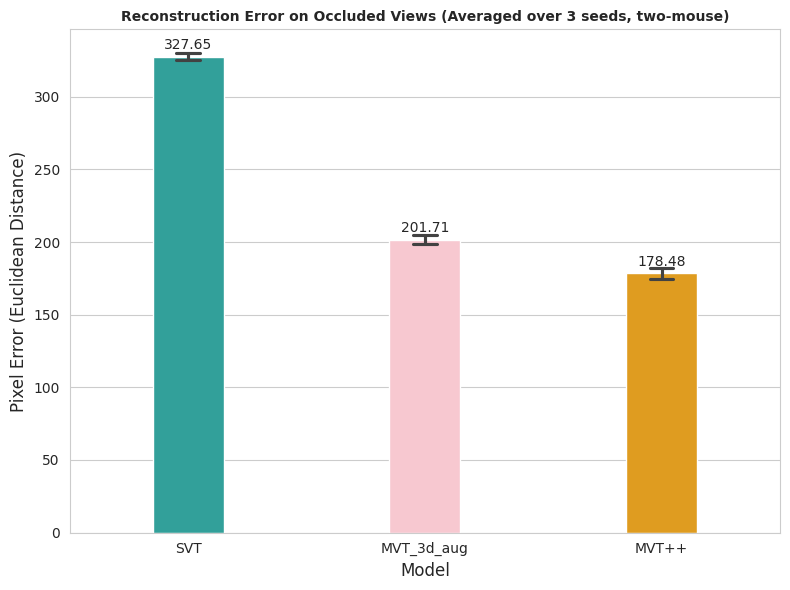


Summary Statistics (Aggregated across seeds):
              count        mean         std       min        max
Model                                                           
MVT++       12522.0  178.483694  202.836291  0.410933  1073.9136
MVT_3d_aug  12522.0  201.712440  180.805556  0.389736  1123.4800
SVT         12522.0  327.647422  128.671456  5.554904   717.2021


In [ ]:
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # -----------------------------------------------------------------------------
# # Configuration
# # -----------------------------------------------------------------------------

# # dataset_name = "mirror-mouse-separate"
# dataset_name = "fly-anipose"
# # dataset_name = "chickadee-crop"
# # dataset_name = "ibl-mouse"
# # dataset_name = "two-mouse"
# # Base path where the seed folders are located
# # Assuming structure: /teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR_seed{seed}
# BASE_OUTPUT_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}"

# # Dataset specific view names (Ensure these match your dataset)
# # Example for fly: ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# # Example for chickadee: ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
# # Example for mouse: ['top', 'bot']
# # VIEWS = ['top', 'bot']  # UPDATE THIS for your current dataset!
# VIEWS = ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# # VIEWS = ["lBack", "lFront", "lTop", "rBack", "rFront", "rTop"]
# # VIEWS = ['leftCamera', 'rightCamera']
# # VIEWS = ['Camera0', 'Camera1', 'Camera2', 'Camera3', 'Camera4']
# # MODELS = ["SVT", "MVT_3d_aug", "MVT_3d_loss", "MVT_patch_masking", "MVT++"]
# MODELS = ["SVT", "MVT_3d_aug", "MVT++"]
# SEEDS = [0, 1, 2]
# # SEEDS = [0,1]

# # model_colors = {
# #     "SVT": "lightseagreen",
# #     "MVT": "pink", 
# #     "MVT_3d_aug": "pink", # Optional if in your list
# #     "MVT_3d_loss": "green",
# #     "MVT_patch_masking": "orange", # Optional if in your list
# #     "MVT++": "purple"
# # }

# # this is for mouse dataset
# model_colors = {
#     "SVT": "lightseagreen",
#     "MVT": "pink", 
#     "MVT_3d_aug": "pink", # Optional if in your list
#     "MVT_3d_loss": "green",
#     "MVT_patch_masking": "orange", # Optional if in your list
#     "MVT++": "orange"
# }

# # -----------------------------------------------------------------------------
# # Collect Data Across Seeds
# # -----------------------------------------------------------------------------

# aggregated_errors = []

# print(f"Collecting errors from seeds: {SEEDS}")

# for seed in SEEDS:
#     seed_dir = os.path.join(BASE_OUTPUT_DIR, f"occlusion_experiments_ICLR_seed{seed}")
    
#     if not os.path.exists(seed_dir):
#         print(f"Warning: Directory not found for seed {seed}: {seed_dir}")
#         continue
        
#     print(f"  Processing seed {seed}...")
    
#     for model in MODELS:
#         model_errors = []
        
#         for masked_view in VIEWS:
#             # Construct path: seed_dir / Model / masked_ViewX / CollectedData_ViewX_new_pixel_error.csv
#             # We strictly look for the error file corresponding to the view that was masked.
#             error_file_path = os.path.join(
#                 seed_dir, 
#                 model, 
#                 f"masked_{masked_view}", 
#                 f"CollectedData_{masked_view}_new_pixel_error.csv"
#             )
            
#             if not os.path.exists(error_file_path):
#                 # Try finding it without "CollectedData_" prefix if that convention varies
#                 alt_path = os.path.join(
#                     seed_dir, 
#                     model, 
#                     f"masked_{masked_view}", 
#                     f"predictions_{masked_view}_new_pixel_error.csv"
#                 )
#                 if os.path.exists(alt_path):
#                     error_file_path = alt_path
#                 else:
#                     # print(f"    Warning: Missing file for {model} masked {masked_view}")
#                     continue
                
#             try:
#                 # Load error CSV
#                 df = pd.read_csv(error_file_path, index_col=0)
    
                
#                 # Filter out 'set' column if it exists
#                 if 'set' in df.columns:
#                     df = df.drop(columns=['set'])
                    
#                 # Flatten all errors (across frames and keypoints) for this masked view
#                 errors = df.values.flatten()
                
#                 # Remove NaNs if any
#                 errors = errors[~np.isnan(errors)]
                
#                 model_errors.extend(errors)
                
#             except Exception as e:
#                 print(f"    Error processing {error_file_path}: {e}")

#         if not model_errors:
#             # print(f"    No data found for model {model} in seed {seed}")
#             continue

#         # Store result for this model & seed
#         for err in model_errors:
#             aggregated_errors.append({
#                 "Model": model,
#                 "Seed": seed,
#                 "Pixel Error": err
#             })

# print(f"Collected {len(aggregated_errors)} total error points.")

# # -----------------------------------------------------------------------------
# # Plotting
# # -----------------------------------------------------------------------------

# if aggregated_errors:
#     df_plot = pd.DataFrame(aggregated_errors)
    
#     # Set style
#     sns.set_style("whitegrid")
#     plt.figure(figsize=(8, 6))
    
#     # Create Bar Plot (Aggregated across seeds)
#     # The error bars will now represent variability across all data points from all seeds
#     ax = sns.barplot(
#         data=df_plot, 
#         x="Model", 
#         y="Pixel Error", 
#         hue="Model", 
#         palette=model_colors, 
#         errorbar=('ci', 95), 
#         capsize=0.1,
#         width=0.3
#     )
    
#     # Customize
#     plt.title(f"Reconstruction Error on Occluded Views (Averaged over {len(SEEDS)} seeds, {dataset_name})", fontsize=10, fontweight='bold')
#     plt.ylabel("Pixel Error (Euclidean Distance)", fontsize=12)
#     plt.xlabel("Model", fontsize=12)
    
#     # Add values on top
#     for container in ax.containers:
#         ax.bar_label(container, fmt='%.2f', padding=3)
        
#     plt.tight_layout()

#     # save the plot in a folder inside /teamspace/studios/this_studio/outputs/{dataset_name}/plots
#     plot_dir = os.path.join(BASE_OUTPUT_DIR, "plots", "occlusion_error_plots")
#     os.makedirs(plot_dir, exist_ok=True)
#     plt.savefig(os.path.join(plot_dir, f"occlusion_error_plot_{dataset_name}.pdf"))

#     plt.show()
    
#     # Print summary stats
#     print("\nSummary Statistics (Aggregated across seeds):")
#     print(df_plot.groupby("Model")["Pixel Error"].describe()[['count', 'mean', 'std', 'min', 'max']])
    
#     # Optional: Print stats per seed to check consistency
#     # print("\nMean Error per Model per Seed:")
#     # print(df_plot.groupby(["Model", "Seed"])["Pixel Error"].mean())
    
# else:
#     print("No data to plot.")

Collected 18 R² values (one per masked view per model).


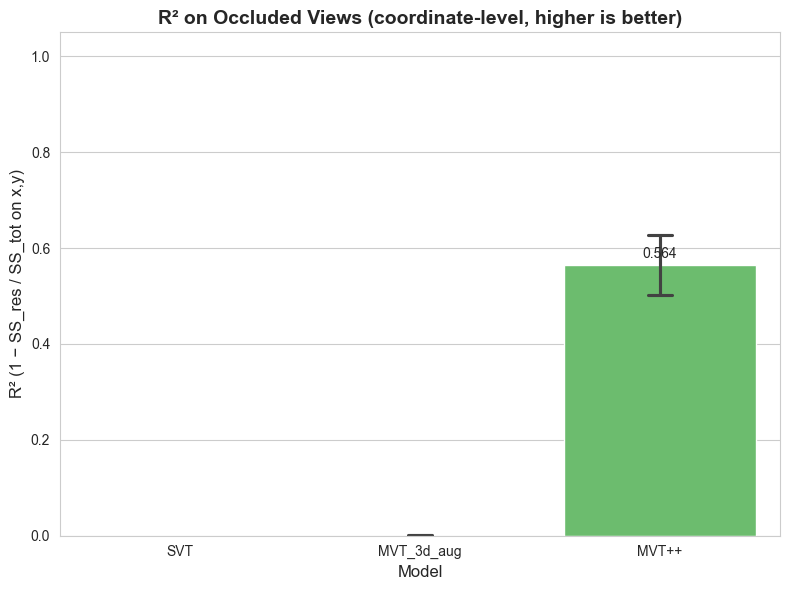


Summary Statistics:
            count      mean       std       min       max
Model                                                    
MVT++         6.0  0.564146  0.084337  0.479669  0.672341
MVT_3d_aug    6.0 -0.182859  0.261648 -0.507364  0.229389
SVT           6.0 -0.018480  0.002254 -0.020906 -0.015040


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# R² version — requires running inference cell first (saves *_new_r2.csv per view).
# One R² per occluded-view condition (pooled x,y MSE vs variance of GT); higher is better.
# -----------------------------------------------------------------------------

# RESULTS_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR"
RESULTS_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}/occlusion_experiments_ICLR_seed0_r2"
MODELS = ["SVT", "MVT", "MVT++"]
# VIEWS = ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# VIEWS = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
VIEWS = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
aggregated_r2 = []

print(f"Collecting R² from: {RESULTS_DIR}")

for model in MODELS:
    model_r2 = []

    for masked_view in VIEWS:
        r2_file_path = os.path.join(
            RESULTS_DIR,
            model,
            f"masked_{masked_view}",
            f"CollectedData_{masked_view}_new_r2.csv",
        )

        if not os.path.exists(r2_file_path):
            print(f"Warning: Missing file {r2_file_path}")
            continue

        try:
            df = pd.read_csv(r2_file_path)
            r2_val = float(df["r2"].iloc[0])
            if not np.isfinite(r2_val):
                continue
            model_r2.append(r2_val)
        except Exception as e:
            print(f"Error processing {r2_file_path}: {e}")

    if not model_r2:
        print(f"No R² data found for model {model}")
        continue

    for r2v in model_r2:
        aggregated_r2.append({"Model": model, "R2": r2v})

print(f"Collected {len(aggregated_r2)} R² values (one per masked view per model).")

if aggregated_r2:
    df_plot = pd.DataFrame(aggregated_r2)

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=df_plot,
        x="Model",
        y="R2",
        hue="Model",
        palette="viridis",
        errorbar=("ci", 95),
        capsize=0.1,
    )

    plt.title(
        "R² on Occluded Views (coordinate-level, higher is better)",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("R² (1 − SS_res / SS_tot on x,y)", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    plt.ylim(0, 1.05)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.show()

    print("\nSummary Statistics:")
    print(df_plot.groupby("Model")["R2"].describe()[["count", "mean", "std", "min", "max"]])
else:
    print("No data to plot.")


  Processing seed 0...
r2_val: -1.0772348360775412
r2_val: -0.4740505656138321
r2_val: -1.723385965618612
r2_val: -2.3125328120913795
r2_val: -1.793587644935048
r2_val: -1.991328905828981
Collected 6 total R² values.


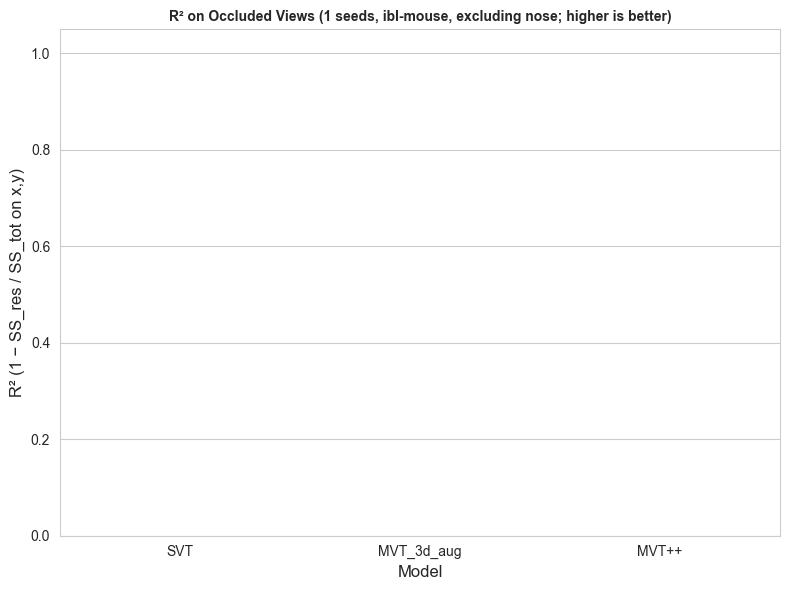


Summary Statistics (aggregated across seeds, excluding nose):
            count      mean       std       min       max
Model                                                    
MVT++         2.0 -1.892458  0.139824 -1.991329 -1.793588
MVT_3d_aug    2.0 -2.017959  0.416590 -2.312533 -1.723386
SVT           2.0 -0.775643  0.426516 -1.077235 -0.474051


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# R² version (multi-seed) — same layout as pixel-error multi-seed cell
# -----------------------------------------------------------------------------

# dataset_name = "two-mouse"
# dataset_name = "fly-anipose"
# dataset_name = "chickadee-crop"
dataset_name = "ibl-mouse"
BASE_OUTPUT_DIR = f"/teamspace/studios/this_studio/outputs/{dataset_name}"

# VIEWS = ["Cam-A", "Cam-B", "Cam-C", "Cam-D", "Cam-E", "Cam-F"]
# VIEWS = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']
VIEWS = ['leftCamera', 'rightCamera']
MODELS = ["SVT", "MVT_3d_aug", "MVT++"]
SEEDS = [0]

model_colors = {
    "SVT": "lightseagreen",
    "MVT": "pink",
    "MVT_3d_aug": "pink",
    "MVT_3d_loss": "green",
    "MVT_patch_masking": "orange",
    "MVT++": "orange",
}

aggregated_r2 = []

print(f"Collecting R² from seeds: {SEEDS}")

for seed in SEEDS:
    seed_dir = os.path.join(BASE_OUTPUT_DIR, f"occlusion_experiments_ICLR_seed{seed}_r2")

    if not os.path.exists(seed_dir):
        print(f"Warning: Directory not found for seed {seed}: {seed_dir}")
        continue

    print(f"  Processing seed {seed}...")

    for model in MODELS:
        model_r2 = []

        for masked_view in VIEWS:
            r2_file_path = os.path.join(
                seed_dir,
                model,
                f"masked_{masked_view}",
                f"CollectedData_{masked_view}_new_r2.csv",
            )

            if not os.path.exists(r2_file_path):
                alt_path = os.path.join(
                    seed_dir,
                    model,
                    f"masked_{masked_view}",
                    f"predictions_{masked_view}_new_r2.csv",
                )
                if os.path.exists(alt_path):
                    r2_file_path = alt_path
                else:
                    continue

            try:
                df = pd.read_csv(r2_file_path)
                r2_val = float(df["r2"].iloc[0])
                print(f"r2_val: {r2_val}")
                if not np.isfinite(r2_val):
                    continue
                model_r2.append(r2_val)
            except Exception as e:
                print(f"    Error processing {r2_file_path}: {e}")

        if not model_r2:
            continue

        for r2v in model_r2:
            aggregated_r2.append({"Model": model, "Seed": seed, "R2": r2v})

print(f"Collected {len(aggregated_r2)} total R² values.")

if aggregated_r2:
    df_plot = pd.DataFrame(aggregated_r2)

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=df_plot,
        x="Model",
        y="R2",
        hue="Model",
        palette=model_colors,
        errorbar=("ci", 95),
        capsize=0.1,
        width=0.3,
    )

    plt.title(
        f"R² on Occluded Views ({len(SEEDS)} seeds, {dataset_name}; higher is better)",
        fontsize=10,
        fontweight="bold",
    )
    plt.ylabel("R² (1 − SS_res / SS_tot on x,y)", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    plt.ylim(0, 1.05)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()

    plot_dir = os.path.join(BASE_OUTPUT_DIR, "plots", "occlusion_error_plots")
    os.makedirs(plot_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_dir, f"occlusion_r2_plot_{dataset_name}.pdf"))

    plt.show()

    print("\nSummary Statistics (aggregated across seeds):")
    print(df_plot.groupby("Model")["R2"].describe()[["count", "mean", "std", "min", "max"]])
else:
    print("No data to plot.")
